# Brand value and the sponsorship's incremental brand value

**Review notebook** for `brand_value_dcf_v1` (ISO 10668 branded-earnings DCF, ADR-0033), `brand_value_dominance_v1` (brand share of share-price formation and the Index-lift chain, ADR-0031/0032), and the comparison routes `sponsorship_total_return_v3` and `valuation_routes_v1` (ADR-0030). It follows the human-review standard in `AGENTS.md`.

> **Status: planning valuation, not accepted.** The brand-share input is an owner-selected proxy and the sponsorship lift it is applied to is not yet statistically confirmed (see `10_total_sponsorship_effect.ipynb`). Quote any figure here only with its range and these caveats.

*How to use:* run all cells. Read-only unless `RUN_REBUILD = True`. Narrative numbers are computed from current outputs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: re-runs the valuation experiments (about a minute)
    for module in ["srmp.experiments.sponsorship_total_return_v3", "srmp.experiments.valuation_routes_v1",
                   "srmp.experiments.brand_value_dominance_v1", "srmp.experiments.brand_value_dcf_v1"]:
        subprocess.run([sys.executable, "-m", module], check=True)

E = "data/curated/experimental/"
SOURCES = [
    "data/reference/lenovo_annual_financials.csv", "data/reference/lenovo_quarterly_financials.csv",
    "config/experiments/brand_value_dcf_v1.yaml", "config/experiments/brand_value_dominance_v1.yaml",
    E + "brand_value_dcf_v1/brand_value_dcf_manifest.json", E + "brand_value_dcf_v1/economic_profit_forecast.parquet",
    E + "brand_value_dcf_v1/sensitivity_grid.parquet",
    E + "brand_value_dominance_v1/brand_value_dominance_manifest.json", E + "brand_value_dominance_v1/dominance_weights.parquet",
    E + "brand_value_dominance_v1/stability.parquet",
    E + "sponsorship_total_return_v3/total_return_v3_manifest.json",
    E + "valuation_routes_v1/valuation_routes.parquet", E + "valuation_routes_v1/breakeven.parquet",
    E + "sponsorship_total_effect_v1/estimate_manifest.json",
]
stamp_sources(SOURCES)
dcf = json.loads(Path(E + "brand_value_dcf_v1/brand_value_dcf_manifest.json").read_text())
dom = json.loads(Path(E + "brand_value_dominance_v1/brand_value_dominance_manifest.json").read_text())

REVIEW_SOURCES={"data/reference/lenovo_annual_financials.csv": "f8f58adc1d053fded7398b23d1041c6ffb52cb9b2bac06bdd6829a6d21f69bee", "data/reference/lenovo_quarterly_financials.csv": "e418999c1ccf5806c79b09a2b7819069636b3a83e2949a259c84a66b52e4b1ab", "config/experiments/brand_value_dcf_v1.yaml": "8eb4ec48927e4484f9c7846f036595c463252185eff2f4f6b5ec6abc1f016ee9", "config/experiments/brand_value_dominance_v1.yaml": "28f51cebb39641cc4b033533e466b90fcae9d35b55f535e3abbc902661f3e814", "data/curated/experimental/brand_value_dcf_v1/brand_value_dcf_manifest.json": "5eefe1f2f5a269253e7a25379b751c109600d6079986e0f7affe9780cdbf651f", "data/curated/experimental/brand_value_dcf_v1/economic_profit_forecast.parquet": "c6b868d91973970d5ee293c3384d499fb4ccc5b75646bc411248c257d1ac0e4f", "data/curated/experimental/brand_value_dcf_v1/sensitivity_grid.parquet": "ef744837cda8fb26e8f8a504ba8113348c21f496ac77df0a79e59125b0661d14", "data/curated/experimental/brand_value_dominance_v1/brand_value_dominance_manifes

## 1. Question and purpose

**Questions.** (a) What is the Lenovo brand worth? (b) Given the sponsorship's measured lift in brand salience, how much incremental brand value does that lift imply?

**Why it matters.** The client needs a money translation of the sponsorship's brand effect. This notebook makes every step of that translation explicit, so the size of each assumption is visible.

**Objective supported.** Monetisation of the sponsorship's brand uplift (downstream of, and conditional on, the uplift analysis).

## 2. Evidence and inputs

| Input | Value / source | Label |
|---|---|---|
| FY25/26 revenue, operating profit, profit before tax, tax | Lenovo results release (FY ending 31 Mar 2026) | **observed** |
| Equity, debt, cash, short-term investments at 31 Mar 2026 | Balance sheet via stockanalysis.com | **observed** (secondary source) |
| Revenue growth path | Starts at the trailing 3-year CAGR, fades linearly to 3% by year 5 | **assumed** (rule-based) |
| Operating margin, tax rate, capital turnover | Held at FY25/26 levels | **assumed** |
| Risk-free rate | US 10-year Treasury yield, latest close | **observed** |
| Equity beta | Lenovo vs MSCI ACWI, 104 weekly USD returns, Blume-adjusted | **estimated** |
| Equity risk premium 5.0%, debt spread 150bp | Valuation convention | **assumed** |
| Role of brand (brand share of economic profit) | Brand's share of share-price formation (dominance analysis) | **estimated** proxy, chosen by the project owner |
| Brand Finance 2025 brand value US$5.66bn | Brand Finance China 500 2025 | **borrowed** (external cross-check only) |
| Sponsorship lift | Synthetic-control sustained gap | **estimated**, not statistically accepted |
| Brand value elasticity to salience = 1 | Proportionality | **assumed** |

## 3. Method and formulas

**Economic profit (EP).** For forecast year $t$:

$$\text{NOPAT}_t = R_t \cdot m \cdot (1-\tau), \qquad \text{EP}_t = \text{NOPAT}_t - \text{WACC} \cdot IC_{t-1}.$$

$R_t$ revenue, $m$ operating margin, $\tau$ effective tax rate, $IC$ invested capital (equity + debt − cash − short-term investments), growing with revenue. *In words:* the after-tax operating profit left over once investors are paid a fair return on the capital the business uses.

**Branded earnings and brand value (ISO 10668 income approach, earnings split).**

$$BE_t = \rho \cdot \text{EP}_t, \qquad BV = \sum_{t=1}^{5} \frac{BE_t}{(1+\text{WACC})^t} + \frac{\rho \cdot \text{EP}_6}{(\text{WACC}-g)(1+\text{WACC})^5}.$$

$\rho$ is the **role of brand**, the share of economic profit attributed to the brand; $g$ the terminal growth rate. *In words:* the brand is worth the present value of its share of the company's economic profit.

**WACC.** $k_e = r_f + \beta \cdot ERP$, $k_d = (r_f + s)(1-\tau)$, $\text{WACC} = (1-w_d)k_e + w_d k_d$ with $w_d$ = debt / (debt + market capitalisation).

**Role of brand from dominance analysis (owner-selected proxy).** Weekly Lenovo log returns are regressed on groups of drivers (market factors, category demand, Lenovo events, brand-index innovation). General dominance splits the model's $R^2$ into each group's average incremental contribution across all orderings (Shapley–Owen). The brand's share, signed by its coefficient so that adverse co-movement is not counted as value, is taken as $\rho$. Two readings exist: share of *all* explained movement (literal) and share of the *Lenovo-specific* drivers only (excluding the market factors, since economic profit is Lenovo-specific).

**From Index lift to incremental brand value.** The Brand Index is an exact linear function of Lenovo's search interest, $I = a + b \cdot s$, so $s = 0$ maps to $I_0 = a$. A lift $\Delta$ above a no-sponsorship level $I_{cf}$ is a salience uplift

$$u = \frac{\Delta}{I_{cf} - I_0}, \qquad \Delta BV = \varepsilon \cdot u \cdot BV, \qquad \text{coefficient} = \frac{\varepsilon\, BV}{I_{cf} - I_0}\ \text{per Index point}.$$

*In words:* the lift is converted into "percent more brand search salience", and brand value is assumed to move one-for-one ($\varepsilon = 1$) with salience.

## 4. Calculation path

| Step | Code | Configuration | Output |
|---|---|---|---|
| Stock-return drivers, brand innovation | `srmp/experiments/stock_brand_response_v2.py` | `config/experiments/stock_brand_response_v2.yaml` | `stock_brand_response_v2/` |
| Dominance shares, salience map, Index-lift chain | `srmp/experiments/brand_value_dominance_v1.py` (`group_dominance`, `_salience_map`) | `config/experiments/brand_value_dominance_v1.yaml` | `brand_value_dominance_v1/` |
| Sustained lift and market-implied valuation (v3) | `srmp/experiments/sponsorship_total_return_v3.py` | `config/experiments/sponsorship_total_return_v3.yaml` | `sponsorship_total_return_v3/` |
| Economic-profit DCF | `srmp/experiments/brand_value_dcf_v1.py` (`_forecast`, `_wacc`, `_brand_value`) | `config/experiments/brand_value_dcf_v1.yaml` | `brand_value_dcf_v1/` |
| Route comparison and breakevens | `srmp/experiments/valuation_routes_v1.py` | `config/experiments/valuation_routes_v1.yaml` | `valuation_routes_v1/` |

## 5. Results

### 5.1 Base year and discount rate

In [2]:
b, w = dcf["base_year"], dcf["discount_rate"]
display(pd.DataFrame([
    ("Revenue (US$m)", f"{b['revenue']:,.0f}"), ("Operating margin", f"{100*b['operating_margin']:.2f}%"),
    ("Effective tax rate", f"{100*b['tax_rate']:.1f}%"), ("Invested capital (US$m)", f"{b['invested_capital']:,.0f}"),
    ("Return on invested capital", f"{100*b['return_on_invested_capital']:.1f}%"),
    ("Risk-free rate (US 10y)", f"{100*w['risk_free']:.2f}%"), ("Beta vs ACWI (raw → adjusted)", f"{w['raw_beta']:.2f} → {w['beta']:.2f}"),
    ("Equity risk premium", f"{100*w['equity_risk_premium']:.1f}%"), ("Cost of equity", f"{100*w['cost_of_equity']:.2f}%"),
    ("After-tax cost of debt", f"{100*w['after_tax_cost_of_debt']:.2f}%"), ("Debt weight", f"{100*w['weight_debt']:.1f}%"),
    ("WACC", f"{100*w['wacc']:.2f}%"), ("Growth: start → terminal", f"{100*dcf['revenue_growth']['start']:.1f}% → {100*dcf['revenue_growth']['terminal']:.1f}%"),
], columns=[f"{b['fiscal_year']} base year and discount rate", "Value"]).set_index(f"{b['fiscal_year']} base year and discount rate"))

,Value
FY25/26 base year and discount rate,
Revenue (US$m),"83,075"
Operating margin,3.93%
Effective tax rate,19.1%
Invested capital (US$m),"8,661"
Return on invested capital,30.5%
Risk-free rate (US 10y),5.30%
Beta vs ACWI (raw → adjusted),1.05 → 1.03
Equity risk premium,5.0%
Cost of equity,10.47%


In [3]:
fc = pd.read_parquet(E + "brand_value_dcf_v1/economic_profit_forecast.parquet")
show = fc[["year", "revenue_growth", "revenue_usd_m", "nopat_usd_m", "capital_charge_usd_m", "economic_profit_usd_m"]].rename(columns={
    "year": "Year", "revenue_growth": "Revenue growth", "revenue_usd_m": "Revenue (US$m)", "nopat_usd_m": "NOPAT (US$m)",
    "capital_charge_usd_m": "Capital charge (US$m)", "economic_profit_usd_m": "Economic profit (US$m)"})
display(show.style.format({"Revenue growth": "{:.1%}", "Revenue (US$m)": "{:,.0f}", "NOPAT (US$m)": "{:,.0f}",
                           "Capital charge (US$m)": "{:,.0f}", "Economic profit (US$m)": "{:,.0f}"}).hide(axis="index"))
pv_ep = dcf["primary_result"]["brand_value_usd_m"] / dcf["primary_result"]["role_of_brand"]
md(f"**Table 2.** Economic-profit forecast. Present value of all economic profit (explicit + terminal): **US${pv_ep/1000:.1f}bn**. "
   "Brand value is the role-of-brand share of this amount.")

Year,Revenue growth,Revenue (US$m),NOPAT (US$m),Capital charge (US$m),Economic profit (US$m)
1,10.3%,"91,611","2,910",871,"2,039"
2,8.5%,"99,359","3,156",960,"2,196"
3,6.6%,"105,954","3,366","1,042","2,324"
4,4.8%,"111,060","3,528","1,111","2,417"
5,3.0%,"114,392","3,634","1,164","2,469"


**Table 2.** Economic-profit forecast. Present value of all economic profit (explicit + terminal): **US$30.9bn**. Brand value is the role-of-brand share of this amount.

### 5.2 Role of brand: what share of the share price does the brand explain?

In [4]:
wts = pd.read_parquet(E + "brand_value_dominance_v1/dominance_weights.parquet")
display(wts.rename(columns={"group": "Driver group", "dominance_r2": "Dominance (R² points)", "share_of_explained": "Share of explained movement",
                            "signed_share_of_explained": "Signed share"}).drop(columns="model")
        .style.format({"Dominance (R² points)": "{:.4f}", "Share of explained movement": "{:.1%}", "Signed share": "{:.2%}"}, na_rep="—").hide(axis="index"))
stab = pd.read_parquet(E + "brand_value_dominance_v1/stability.parquet")
display(stab.rename(columns={"check": "Stability check", "weeks": "Weeks", "r2": "Model R²", "brand_share_of_explained": "Brand share (literal)",
                             "brand_value_usd_m": "Brand value on post-announcement cap (US$m)", "incremental_brand_value_usd_m": "Incremental BV (US$m)"})
        .style.format({"Model R²": "{:.3f}", "Brand share (literal)": "{:.2%}", "Brand value on post-announcement cap (US$m)": "{:,.0f}",
                       "Incremental BV (US$m)": "{:,.1f}"}).hide(axis="index"))
roles = dcf["role_of_brand"]["values"]
md(f"**Tables 3–4.** Market factors explain most weekly movement; the brand group explains little. Literal brand share: **{100*roles['share_of_price_formation']:.2f}%**; "
   f"share of the Lenovo-specific drivers only: **{100*roles['firm_specific_share']:.1f}%**. The stability checks show the share changes several-fold with the "
   "sample and the control groups: share-price data cannot pin the brand's role down precisely.")

Driver group,Dominance (R² points),Share of explained movement,Signed share
market,0.1635,93.4%,—
category_demand,0.0038,2.2%,-2.16%
lenovo_events,0.0071,4.1%,—
brand,0.0007,0.4%,0.42%


Stability check,Weeks,Model R²,Brand share (literal),Brand value on post-announcement cap (US$m),Incremental BV (US$m)
sample 2022-01-01 to 2024-10-14,62,0.363,3.33%,706,67.8
sample 2024-10-15 to 2026-12-31,102,0.157,1.34%,284,27.3
sample 2022-01-01 to 2025-12-31,125,0.354,0.66%,140,13.5
without market,164,0.009,2.22%,471,45.3
without category_demand,164,0.172,0.19%,40,3.9
without lenovo_events,164,0.164,0.31%,65,6.3
brand measured as delta_brand_index,164,0.179,1.36%,289,27.8


**Tables 3–4.** Market factors explain most weekly movement; the brand group explains little. Literal brand share: **0.42%**; share of the Lenovo-specific drivers only: **6.4%**. The stability checks show the share changes several-fold with the sample and the control groups: share-price data cannot pin the brand's role down precisely.

### 5.3 Brand value under each role-of-brand reading

In [5]:
by_role = pd.DataFrame(dcf["by_role_definition"]).T
cross = dcf["cross_check"]
by_role.loc["implied by Brand Finance 2025"] = {"role_of_brand": cross["role_of_brand_implied_by_brand_finance"],
                                                "brand_value_usd_m": cross["brand_finance_2025_usd_m"]}
by_role["incremental_brand_value_usd_m"] = by_role["brand_value_usd_m"] * dcf["primary_result"]["salience_uplift_pct"] / 100
by_role["coefficient_usd_m_per_index_point"] = by_role["incremental_brand_value_usd_m"] / dom["primary_result"]["sustained_lift_index_points"]
display(by_role[["role_of_brand", "brand_value_usd_m", "incremental_brand_value_usd_m", "coefficient_usd_m_per_index_point"]].rename(columns={
    "role_of_brand": "Role of brand", "brand_value_usd_m": "Brand value (US$m)", "incremental_brand_value_usd_m": "Incremental brand value (US$m)",
    "coefficient_usd_m_per_index_point": "US$m per Index point"}).style.format({"Role of brand": "{:.2%}", "Brand value (US$m)": "{:,.0f}",
    "Incremental brand value (US$m)": "{:,.0f}", "US$m per Index point": "{:,.0f}"}))
md(f"**Table 5.** Incremental brand value uses the sustained lift of {fmt(dom['primary_result']['sustained_lift_index_points'], signed=True)} Index points "
   f"(= {fmt(dcf['primary_result']['salience_uplift_pct'], 1, True)}% salience) and elasticity {dcf['primary_result']['elasticity_to_salience']:.0f}. "
   "The Brand Finance row reverses the DCF to find the role of brand its published value implies.")

,Role of brand,Brand value (US$m),Incremental brand value (US$m),US$m per Index point
share_of_price_formation,0.42%,131,13,14
firm_specific_share,6.40%,"1,979",190,209
implied by Brand Finance 2025,18.32%,"5,663",544,599


**Table 5.** Incremental brand value uses the sustained lift of +0.91 Index points (= +9.6% salience) and elasticity 1. The Brand Finance row reverses the DCF to find the role of brand its published value implies.

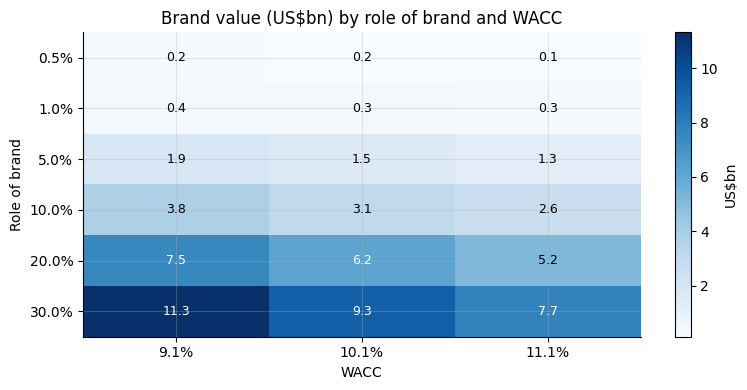

**Figure 1.** Terminal growth held at the base case. Brand value scales one-for-one with the role of brand; moving the WACC from 10.1% down 1 point raises it by 22% and up 1 point lowers it by 17%. The role of brand, which spans a 60-fold range here, is by far the dominant uncertainty.

In [6]:
grid = pd.read_parquet(E + "brand_value_dcf_v1/sensitivity_grid.parquet")
g = grid[grid["role_of_brand"].str.startswith("grid") & grid["terminal_growth"].round(4).eq(round(dcf["revenue_growth"]["terminal"], 4))]
heat = g.pivot(index="role_value", columns="wacc", values="brand_value_usd_m") / 1000
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heat.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(heat.columns)), [f"{100*c:.1f}%" for c in heat.columns]); ax.set_yticks(range(len(heat.index)), [f"{100*r:.1f}%" for r in heat.index])
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.1f}", ha="center", va="center", fontsize=9, color="black" if heat.values[i, j] < heat.values.max()/2 else "white")
ax.set_xlabel("WACC"); ax.set_ylabel("Role of brand"); ax.set_title("Brand value (US$bn) by role of brand and WACC")
plt.colorbar(im, ax=ax, label="US$bn"); plt.tight_layout(); plt.show()
row = heat.iloc[0]
low, mid, high = row.iloc[0], row.iloc[len(row) // 2], row.iloc[-1]
md(f"**Figure 1.** Terminal growth held at the base case. Brand value scales one-for-one with the role of brand; moving the WACC "
   f"from {100*heat.columns[len(row)//2]:.1f}% down 1 point raises it by {100*(low/mid-1):.0f}% and up 1 point lowers it by {100*(1-high/mid):.0f}%. "
   "The role of brand, which spans a 60-fold range here, is by far the dominant uncertainty.")

### 5.4 Comparison routes (market-implied, profit, royalty, event study, media value)

In [7]:
routes = pd.read_parquet(E + "valuation_routes_v1/valuation_routes.parquet")
display(routes[["route", "link_estimate", "link_lower_95", "link_upper_95", "link_identified", "value_unit", "value_at_measured_level"]].rename(columns={
    "route": "Route", "link_estimate": "Link estimate", "link_lower_95": "95% low", "link_upper_95": "95% high",
    "link_identified": "Link statistically identified", "value_unit": "Value unit", "value_at_measured_level": "Value at measured lift"})
    .style.format({"Link estimate": "{:.4f}", "95% low": "{:.4f}", "95% high": "{:.4f}", "Value at measured lift": "{:,.1f}"}, na_rep="—").hide(axis="index"))
be = pd.read_parquet(E + "valuation_routes_v1/breakeven.parquet")
royalty = be[be["route"].eq("relief_from_royalty")][["cost_usd_m", "required_royalty_uplift_basis_points"]]
display(royalty.rename(columns={"cost_usd_m": "Annual sponsorship cost (US$m)", "required_royalty_uplift_basis_points": "Royalty-rate uplift needed (bp)"})
        .style.format("{:.1f}").hide(axis="index"))
md(f"**Tables 6–7.** No route has a statistically identified brand-to-money link ({', '.join(routes.loc[routes['link_identified'], 'route']) or 'none'} identified). "
   "The breakeven reframes the question: how much would the brand's royalty rate need to rise to cover a given annual cost. "
   "The sponsorship fee is not in the workspace, so costs are a grid.")

Route,Link estimate,95% low,95% high,Link statistically identified,Value unit,Value at measured lift
market_implied_equity_v3,0.0311,-0.0200,0.0822,False,"full-contract equity value, US$m","1,083.6"
market_implied_annual_earnings,0.0015,-0.0138,0.0167,False,"annual earnings-equivalent, US$m",2.7
direct_profit_margin,-0.2707,-1.5363,0.9948,False,"annual adjusted net income, US$m (trailing-four-quarter revenue)",-224.3
relief_from_royalty,—,—,—,False,"annual after-tax royalty saving per 1bp of royalty rate, US$m",—
announcement_event_study,0.0174,—,0.0425,False,"gross event equity value, US$m",306.2
industry_claimed_media_value,—,—,—,False,"media value 2025-05-01 to 2026-04-01, currency not stated",164.7


Annual sponsorship cost (US$m),Royalty-rate uplift needed (bp)
50.0,6.9
100.0,13.7
150.0,20.6
250.0,34.3


**Tables 6–7.** No route has a statistically identified brand-to-money link (none identified). The breakeven reframes the question: how much would the brand's royalty rate need to rise to cover a given annual cost. The sponsorship fee is not in the workspace, so costs are a grid.

## 6. Interpretation

In [8]:
pr = dcf["primary_result"]; fs = dcf["by_role_definition"]["firm_specific_share"]
md(f"""- **Brand value:** under the owner-selected literal reading the brand is worth **US${pr['brand_value_usd_m']:,.0f}m**; using the Lenovo-specific share it is
  **US${fs['brand_value_usd_m']/1000:.2f}bn**; Brand Finance's published US${cross['brand_finance_2025_usd_m']/1000:.2f}bn implies a role of brand of
  {100*cross['role_of_brand_implied_by_brand_finance']:.1f}%. A defensible reporting range is the Lenovo-specific reading as floor and the Brand Finance benchmark as reference.
- **Incremental brand value from the sponsorship:** {fmt(pr['salience_uplift_pct'], 1, True)}% salience applied to those brand values gives
  **US${fs['incremental_brand_value_usd_m']:,.0f}m** (Lenovo-specific) to about **US${by_role.loc['implied by Brand Finance 2025', 'incremental_brand_value_usd_m']:,.0f}m** (Brand Finance benchmark);
  the literal reading gives US${pr['incremental_brand_value_usd_m']:,.0f}m.
- **Reference case:** Lenovo's brand value without the measured salience lift, valued at 31 March 2026 with the latest market rates.
- **Decision relevance:** these are planning figures conditional on (i) the lift being real, which is not yet statistically confirmed, and (ii) the role of brand,
  which share-price data cannot measure precisely. A survey-based drivers analysis of purchase decisions would replace the proxy.""")

- **Brand value:** under the owner-selected literal reading the brand is worth **US$131m**; using the Lenovo-specific share it is
  **US$1.98bn**; Brand Finance's published US$5.66bn implies a role of brand of
  18.3%. A defensible reporting range is the Lenovo-specific reading as floor and the Brand Finance benchmark as reference.
- **Incremental brand value from the sponsorship:** +9.6% salience applied to those brand values gives
  **US$190m** (Lenovo-specific) to about **US$544m** (Brand Finance benchmark);
  the literal reading gives US$13m.
- **Reference case:** Lenovo's brand value without the measured salience lift, valued at 31 March 2026 with the latest market rates.
- **Decision relevance:** these are planning figures conditional on (i) the lift being real, which is not yet statistically confirmed, and (ii) the role of brand,
  which share-price data cannot measure precisely. A survey-based drivers analysis of purchase decisions would replace the proxy.

## 7. Limitations and non-claims

- **Not an accounting or audited value**, and not a causal estimate. ISO 10668 expects the brand's contribution to be supported by behavioural evidence on demand; here a share-price relative-importance proxy stands in for it.
- **Variance share ≠ value share.** A stable brand explains little short-run price movement yet can be worth a lot; this biases the dominance-based role of brand downward.
- **Lift not accepted.** The incremental value inherits the sponsorship lift's borderline significance (placebo p just above 0.10).
- **Lift = headline total effect.** The chain applies the total sponsorship effect from `10_total_sponsorship_effect.ipynb` (borderline significant), so every caveat on that estimate carries over.
- **Assumed parameters:** growth fade, constant margin and capital turnover, ERP, debt spread, elasticity of brand value to salience (= 1).
- **Point-in-time rates and prices:** risk-free rate and market capitalisation are the latest available; brand value scales with them.
- **Cross-check is external:** Brand Finance uses a royalty-relief method and its own brand-strength scoring; the comparison is indicative, not a validation.

## Next steps

1. Add a purchase-drivers question set to the post-World Cup survey to estimate the role of brand from demand (ISO 10668 behavioural analysis).
2. Refresh after each data pull; the total effect will include the full World Cup persistence window after 18 October 2026.
3. Obtain the sponsorship fee and activation cost to turn value into a return on investment.